## Topic: Machine Learning Basics + First Model (Classification)
####Learning Objectives

By the end of today, you will:

- Understand what Machine Learning really is
- Learn types of ML:
  - Supervised
  - Unsupervised
    - Build your first classification model
    - Evaluate model performance

### Step 0 — Install & Import Libraries (Run first)

In [2]:
# Install ML libraries (safe to run in Colab)
!pip install scikit-learn seaborn

# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Step 1 — Load Iris Dataset

This is a famous beginner ML dataset

In [3]:
# Import dataset from sklearn
from sklearn.datasets import load_iris

# Load data
data = load_iris()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column (flower type)
df["target"] = data.target

# Show first rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Target values:
- 0 → Setosa
- 1 → Versicolor
- 2 → Virginica

We want the model to predict flower type.

### Step 2 — Split Data (Train/Test)

Train → learn patterns

Test → evaluate model performance

In [4]:
from sklearn.model_selection import train_test_split

# Features (inputs)
X = df.drop("target", axis=1)

# Target (output)
y = df["target"]

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (120, 4)
Testing data size: (30, 4)


### Step 3 — Train Model (Logistic Regression)

In [5]:
from sklearn.linear_model import LogisticRegression

# Create model
log_model = LogisticRegression(max_iter=200)

# Train model using training data
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

Model has now learned patterns

### Step 4 — Make Predictions

In [6]:
# Predict flower types for test data
y_pred_log = log_model.predict(X_test)

y_pred_log[:10]   # show first predictions

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

### Step 5 — Evaluate Model (Accuracy)

In [7]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", accuracy_log)

Logistic Regression Accuracy: 1.0


### Step 6 — Confusion Matrix (Visualization)

Shows correct vs incorrect predictions.

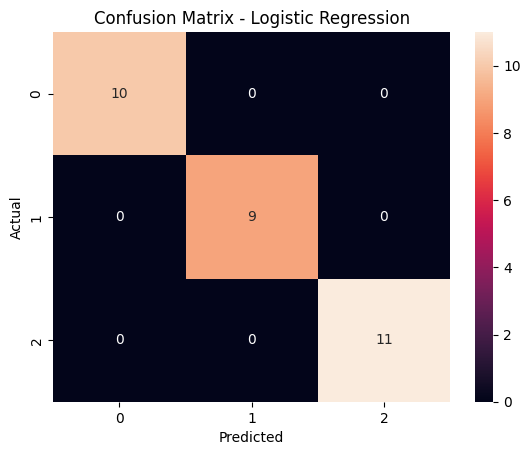

In [8]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Plot heatmap
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Step 7 — Classification Report

Shows detailed performance metrics.

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Important Metrics:
- Precision → correctness of positive predictions
- Recall → how many positives found
- F1-score → balance of precision & recall

### Step 8 — Try Another Model (Decision Tree)

Now we compare models

In [10]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)

# Train model
tree_model.fit(X_train, y_train)

# Predictions
y_pred_tree = tree_model.predict(X_test)

# Accuracy
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 1.0


### Step 9 — Compare Both Models

In [11]:
print("Logistic Regression Accuracy:", accuracy_log)
print("Decision Tree Accuracy:", accuracy_tree)

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


This is real ML workflow:

- Train multiple models
- Compare performance
- Choose best model

### Questions:

#### Q1 — Supervised learning?
Learning using labeled data.

#### Q2 — Classification?
Predicting categories/classes.

#### Q3 — Train-test split?
Train → learn

Test → evaluate

#### Q4 — Overfitting?
Model performs well on training but poorly on new data.